## Análisis exploratorio y modelos predictivos sobre cartera de seguros

**Base:** `cartera_q1_2026_final.parquet`  
**Ramo seleccionado:** `GMM` — Gastos Médicos Mayores  


## 1. Carga de librerías

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
sns.set_theme(style="whitegrid")

## 2. Lectura de la base

In [8]:
ruta_parquet = Path("cartera_q1_2026_final.parquet")

df = pd.read_parquet(ruta_parquet)

df.head()

,id_poliza,num_poliza,nombre,apellido_paterno,apellido_materno,rfc,edad,sexo,estado_civil,ocupacion,...,comision_est,nivel_riesgo,anio_emision,mes_emision,trimestre,segmento_prima_fijo,cuartil_prima,cod_ramo,anio_poliza,ramo_desde_codigo
0,POL-000001,Vid-21-000001,Gabriela,Moreno,Vega,MOGV020429CG6,24,F,Union libre,Independiente,...,"5,892.42",BAJO,2021,11,4,Premium,Q4,VID,2021,Vida
1,POL-000002,Aut-19-000002,Valeria,Torres,Castillo,TOVC020815IA8,23,F,Casado,Contador,...,882.44,BAJO,2019,8,3,Alta,Q1,AUT,2019,Autos
2,POL-000003,GMM-22-000003,Fernanda,Ramos,Silva,RAFS941018BC1,31,M,Union libre,Ingeniero,...,"1,995.46",BAJO,2022,7,3,Premium,Q3,GMM,2022,GMM
3,POL-000004,Vid-19-000004,Silvia,Mendoza,Gutierrez,MESG860204IH8,40,M,Soltero,Arquitecto,...,"14,002.67",BAJO,2019,3,1,Premium,Q4,VID,2019,Vida
4,POL-000005,Vid-20-000005,Antonio,Ramos,Castillo,RAAC960722ME2,29,F,Soltero,Independiente,...,"6,545.88",MEDIO,2020,11,4,Premium,Q4,VID,2020,Vida


### Revisión inicial de la base

Antes de seleccionar el ramo, revisamos el tamaño de la base y las columnas disponibles. Esto nos ayuda a tener una primera idea de qué tan completa está la información y qué variables pueden servir para nuestrp análisis actuarial.

In [9]:
print(f"Filas: {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]:,}")

df.info()

Filas: 50,000
Columnas: 52
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 52 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   id_poliza              50000 non-null  object        
 1   num_poliza             50000 non-null  object        
 2   nombre                 50000 non-null  category      
 3   apellido_paterno       50000 non-null  category      
 4   apellido_materno       50000 non-null  category      
 5   rfc                    50000 non-null  object        
 6   edad                   50000 non-null  int8          
 7   sexo                   50000 non-null  category      
 8   estado_civil           50000 non-null  category      
 9   ocupacion              46000 non-null  category      
 10  ramo                   50000 non-null  category      
 11  plan                   50000 non-null  category      
 12  fecha_emision          50000 non-

## 3. Selección del ramo

Para elegir el ramo, primero revisamos cuántos registros hay en cada uno. Un ramo con más observaciones nos da una base más estable para comparar distribuciones, detectar valores extremos y entrenar modelos.

In [10]:
conteo_ramos = (
    df["ramo"]
    .value_counts()
    .rename_axis("ramo")
    .reset_index(name="registros")
)

conteo_ramos["porcentaje %"] = (
    (conteo_ramos["registros"] / len(df) * 100)
    .round(2)
    .astype(str) + "%"
)

conteo_ramos

,ramo,registros,porcentaje %
0,GMM,22531,45.06%
1,Autos,14752,29.5%
2,Vida,7510,15.02%
3,Accidentes Personales,5207,10.41%


### Interpretación del conteo por ramo

El ramo con mayor número de registros es **GMM**, con  **45.06%** de la cartera total. Por esa razón lo seleccionamos para nuestro análisis.

Por un lado, podemos estudiar cuántos asegurados presentan siniestros y, por otro, analizar qué tan grandes llegan a ser los montos pagados cuando estos ocurren. Este comportamiento es relevante porque normalmente muchos asegurados pueden no generar reclamaciones durante cierto periodo, mientras que algunos pocos casos pueden representar costos mucho más elevados para la aseguradora.

Por esto, trabajar con este ramo nos permit+ira realizar un análisis más completo, ya que podemos revisar patrones en los datos, identificar comportamientos fuera de lo común y aplicar modelos que ayuden a entender mejor cómo se comporta el riesgo

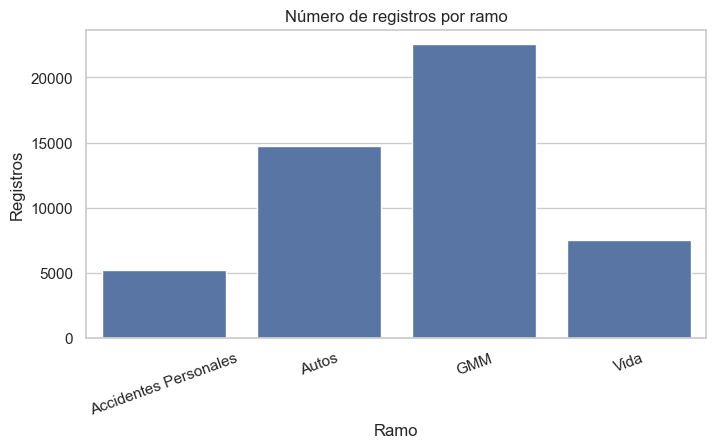

In [11]:
plt.figure(figsize=(8, 4))
sns.barplot(data=conteo_ramos, x="ramo", y="registros")
plt.title("Número de registros por ramo")
plt.xlabel("Ramo")
plt.ylabel("Registros")
plt.xticks(rotation=20)
plt.show()

### Interpretación de la gráfica de ramos

La gráfica confirma que **GMM** es el ramo con más observaciones dentro de la base. Esto hace que sea una buena elección para el análisis, ya que permite trabajar con una muestra amplia y reduce un poco el riesgo de sacar conclusiones a partir de pocos datos.

In [21]:
df_gmm = df[df["ramo"] == "GMM"].copy()

print(f"Registros de GMM: {len(df_gmm):,}")
df_gmm.head()

Registros de GMM: 22,531


,id_poliza,num_poliza,nombre,apellido_paterno,apellido_materno,rfc,edad,sexo,estado_civil,ocupacion,...,comision_est,nivel_riesgo,anio_emision,mes_emision,trimestre,segmento_prima_fijo,cuartil_prima,cod_ramo,anio_poliza,ramo_desde_codigo
2,POL-000003,GMM-22-000003,Fernanda,Ramos,Silva,RAFS941018BC1,31,M,Union libre,Ingeniero,...,"1,995.46",BAJO,2022,7,3,Premium,Q3,GMM,2022,GMM
6,POL-000007,GMM-23-000007,Mario,Reyes,Castillo,REMC680423LH5,58,M,Divorciado,Jubilado,...,"2,236.32",BAJO,2023,3,1,Premium,Q3,GMM,2023,GMM
7,POL-000008,GMM-19-000008,Carlos,Rivera,Sanchez,RICS710805YY4,54,M,Casado,Director,...,629.66,BAJO,2019,3,1,Alta,Q1,GMM,2019,GMM
8,POL-000009,GMM-24-000009,Jose,Nunez,Reyes,NUJR930612XL7,32,M,Union libre,Empresario,...,"10,879.18",BAJO,2024,11,4,Premium,Q4,GMM,2024,GMM
10,POL-000011,GMM-23-000011,Daniel,Ortiz,Martinez,ORDM850718BP5,40,F,Union libre,Analista,...,"1,888.48",MEDIO,2023,5,2,Premium,Q3,GMM,2023,GMM


## 4. Preparación de variables

Se crean algunas variables auxiliares para facilitar el análisis:

- `siniestro_positivo`: identifica si la póliza tuvo al menos un siniestro.
- `monto_pagado_log`: transformación logarítmica del monto pagado para suavizar el efecto de pagos muy grandes.

In [29]:
df_gmm["siniestro_positivo"] = np.where(df_gmm["n_siniestros"].fillna(0) > 0, 1, 0)
#se agrego
df_gmm_reg = df_gmm[df_gmm["monto_pagado"] > 0].copy()
df_gmm_reg["monto_pagado_log"] = np.log1p(df_gmm_reg["monto_pagado"].fillna(0))

df_gmm["monto_pagado_log"] = np.log1p(df_gmm["monto_pagado"].fillna(0))

df_gmm[["n_siniestros", "siniestro_positivo", "monto_pagado", "monto_pagado_log"]].head()

,n_siniestros,siniestro_positivo,monto_pagado,monto_pagado_log
2,0.00,0,0.00,0.00
6,0.00,0,0.00,0.00
7,0.00,0,0.00,0.00
8,0.00,0,0.00,0.00
10,1.00,1,"7,655.00",8.94


In [39]:
df_gmm_reg.shape[0]
#df_gmm.shape[0]

2813

### Interpretación de las variables creadas

La variable `siniestro_positivo` ayuda a separar las pólizas que sí tuvieron a siniestros de las que no tuvieron.

La transformación logarítmica del monto pagado lo usaremos porque los montos de siniestros suelen tener mucha concentración en cero o valores bajos, pero también pueden tener casos muy altos. Con el logaritmo, esos casos extremos siguen estando presentes, pero ya no dominaran tanto el análisis visual y de los modelos.

## 5. Estadísticas descriptivas

A continuación revisaremos algunas variables numéricas importantes del ramo GMM. En donde incluiremos variables de exposición, prima, suma asegurada, deducible y siniestralidad.

In [14]:
variables_numericas = [
    "edad", "prima_total", "suma_asegurada", "deducible",
    "n_siniestros", "monto_reclamado", "monto_pagado", "loss_ratio"
]

resumen_descriptivo = df_gmm[variables_numericas].describe(
    percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
).T

resumen_descriptivo = resumen_descriptivo.rename(
    columns={"50%": "mediana"}
)

resumen_descriptivo.style.format("{:,.2f}") \
    .set_caption("Resumen estadístico de variables numéricas - GMM") \
    .set_table_styles([
        {
            "selector": "caption",
            "props": [
                ("font-size", "16px"),
                ("font-weight", "bold"),
                ("text-align", "center")
            ]
        },
        {
            "selector": "th",
            "props": [
                ("font-weight", "bold"),
                ("text-align", "center")
            ]
        },
        {
            "selector": "td",
            "props": [
                ("text-align", "center")
            ]
        }
    ])

,count,mean,std,min,25%,mediana,75%,90%,95%,99%,max
edad,"22,531.00",43.30,12.97,21.00,32.00,43.00,54.00,61.00,64.00,65.00,66.00
prima_total,"22,531.00","32,445.18","28,387.43","5,104.00","9,493.44","22,049.28","52,571.20","80,388.00","91,366.70","106,062.40","114,931.87"
suma_asegurada,"22,531.00","1,106,999.25","951,412.30","200,000.00","300,000.00","800,000.00","2,000,000.00","3,000,000.00","3,000,000.00","3,000,000.00","3,000,000.00"
deducible,"22,531.00","11,623.54","5,319.32","5,000.00","8,000.00","10,000.00","15,000.00","20,000.00","20,000.00","20,000.00","20,000.00"
n_siniestros,"22,531.00",0.36,0.60,0.00,0.00,0.00,1.00,1.00,2.00,2.00,4.00
monto_reclamado,"22,531.00","13,403.79","37,203.45",0.00,0.00,0.00,"10,300.81","42,182.04","72,690.33","164,773.87","947,321.62"
monto_pagado,"22,531.00","4,301.29","20,609.64",0.00,0.00,0.00,0.00,"6,533.45","25,728.04","89,721.74","698,744.32"
loss_ratio,"22,531.00",0.20,0.80,0.00,0.00,0.00,0.00,0.21,1.31,5.00,5.00


### Interpretación de las estadísticas descriptivas

La edad se mueve dentro de un rango amplio de asegurados adultos, mientras que la prima, la suma asegurada y el deducible muestran distintos niveles de concentración.

Lo más importante está en la parte de siniestros: la mediana de `monto_pagado` es **0**, lo que significa que al menos la mitad de las pólizas no tuvo pago de siniestro en el periodo observado. Sin embargo, el percentil 99 del monto pagado es cercano a **89,72**, y el máximo llega a un valor mucho más alto. Esto muestra que aunque la mayoría de los casos no genera pagos, sí existen eventos grandes que pueden afectar bastante la cartera.

## 6. Distribuciones de variables principales

Graficamos seis variables que ayudan a entender la cartera desde: características de los asegurados, condiciones de sus pólizas y comportamiento de los siniestros.

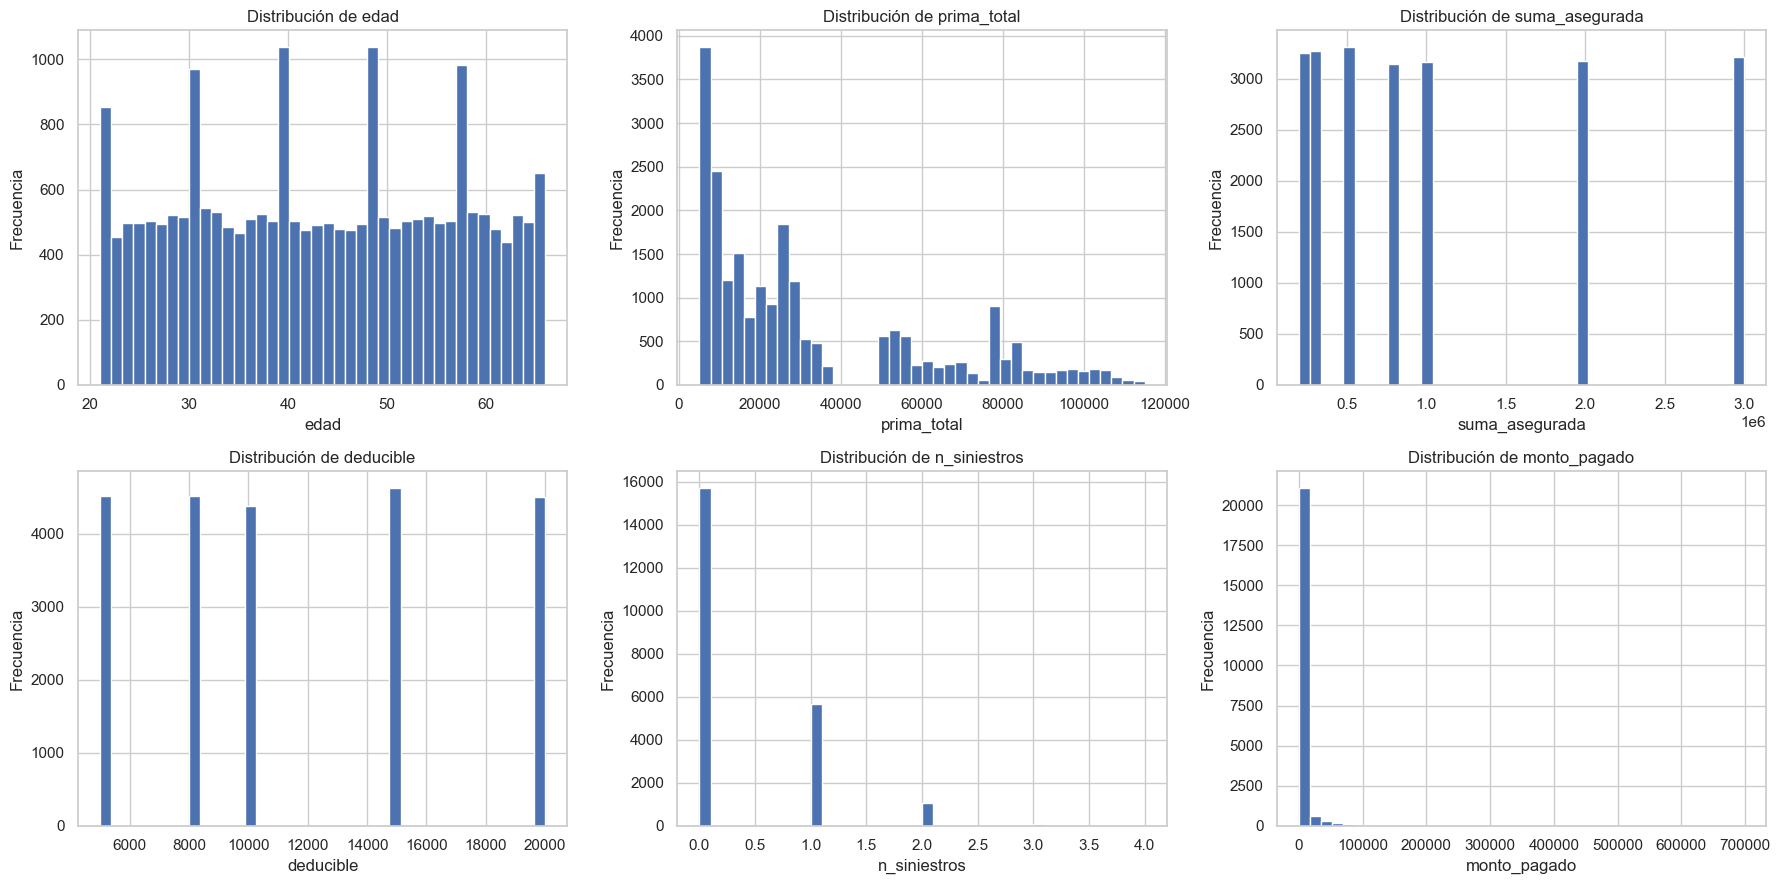

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
axes = axes.ravel()

vars_dist = ["edad", "prima_total", "suma_asegurada", "deducible", "n_siniestros", "monto_pagado"]

for ax, col in zip(axes, vars_dist):
    datos = df_gmm[col].dropna()
    ax.hist(datos, bins=40)
    ax.set_title(f"Distribución de {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()

### Interpretación

Podemos observar que la cartera tiene edades distribuidas en varios rangos, sin que todo se concentre en un solo grupo.

También se ve que la prima total está más cargada hacia montos bajos y medios, mientras que sólo una parte menor tiene primas muy altas. Esto nos hace sentido en una cartera de seguros, porque no todas las pólizas tienen el mismo nivel de cobertura o riesgo.

La suma asegurada y el deducible aparecen en valores muy marcados. Esto probablemente se debe a que las pólizas se ofrecen con planes o en paquetes específicos, esto es importante porque esos niveles definen cuánto podría llegar a pagar y qué parte queda a cargo del asegurado.

En la parte de siniestros, la mayoría de registros se concentra en cero o pocos eventos. El monto pagado también está muy concentrado cerca de cero, pero con algunos pagos muy altos.

## 7. Porcentaje de pólizas con siniestro

Ahora calcularemos en qué proporción de pólizas tuvo al menos un siniestro.

In [22]:
porcentaje_siniestro = df_gmm["siniestro_positivo"].mean() * 100

siniestralidad_tabla = (
    df_gmm["siniestro_positivo"]
    .value_counts()
    .rename(index={0: "Sin siniestro", 1: "Con siniestro"})
    .rename_axis("grupo")
    .reset_index(name="registros")
)

siniestralidad_tabla["porcentaje"] = (
    (siniestralidad_tabla["registros"] / len(df_gmm) * 100)
    .round(2)
    .astype(str) + "%"
)

print(f"Porcentaje de pólizas con siniestro: {porcentaje_siniestro:.2f}%")

siniestralidad_tabla

Porcentaje de pólizas con siniestro: 30.38%


,grupo,registros,porcentaje
0,Sin siniestro,15686,69.62%
1,Con siniestro,6845,30.38%


### Interpretación del porcentaje de siniestros

Aproximadamente **30.38%** de las pólizas de GMM tuvieron al menos un siniestro. Esto quiere decir que la mayoría de los asegurados no presentó reclamaciones durante el periodo analizado.

Desde el punto de vista actuarial, este resultado es importante porque confirma que el riesgo no está repartido de manera uniforme: una parte relativamente menor de la cartera concentra los eventos. Por eso no basta con ver promedios generales; también conviene revisar severidad y valores extremos.

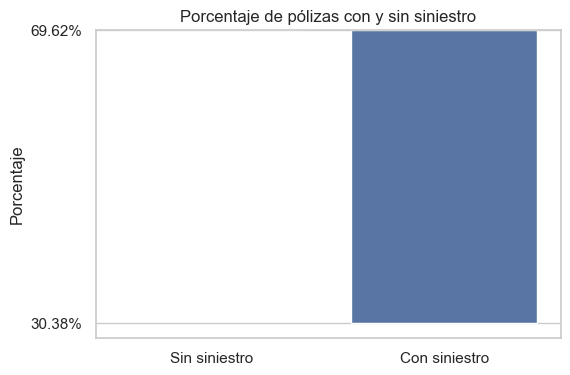

In [23]:
plt.figure(figsize=(6, 4))
sns.barplot(data=siniestralidad_tabla, x="grupo", y="porcentaje")
plt.title("Porcentaje de pólizas con y sin siniestro")
plt.xlabel("")
plt.ylabel("Porcentaje")
plt.show()

### Interpretación

La gráfica deja claro que el grupo sin siniestro es mayor. Esto no significa que el ramo sea necesariamente poco riesgoso, sino que el costo se puede concentrar en menos pólizas.

Este análisis es muy importante, porque un solo siniestro médico grave puede representar un pago alto. Entonces, aunque la frecuencia no sea tan alta, la severidad puede ser el factor que más pese en el resultado final.

## 8. Distribución del monto pagado con transformación logarítmica

Como el monto pagado tiene muchos valores en cero y algunos valores muy altos, revisamos también la versión transformada con logaritmo.

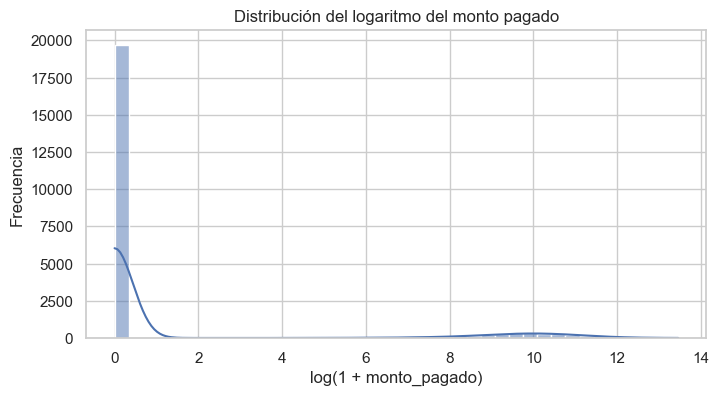

In [24]:
plt.figure(figsize=(8, 4))
sns.histplot(df_gmm["monto_pagado_log"], bins=40, kde=True)
plt.title("Distribución del logaritmo del monto pagado")
plt.xlabel("log(1 + monto_pagado)")
plt.ylabel("Frecuencia")
plt.show()

### Interpretación

Con la transformación logarítmica se alcanza a ver mejor la estructura de los pagos. Sigue existiendo una concentración muy fuerte en cero, pero los montos positivos ya no quedan tan aplastados por los casos extremos.

Esta transformación es útil para modelar, porque los pagos de GMM no se comportan de forma simétrica. Hay muchos registros sin pago y pocos pagos grandes, entonces trabajar con el monto original puede hacer que el modelo se enfoque demasiado en los casos más extremos.

## 9. Correlaciones

Se calcula la matriz de correlación entre las variables numéricas. Esta parte nos ayuda a revisar qué variables se mueven juntas y cuáles podrían estar relacionadas con el monto pagado.

In [ ]:
vars_corr = [
    "edad", "num_renovaciones", "suma_asegurada", "deducible",
    "prima_total", "comision_pct", "n_siniestros",
    "monto_reclamado", "monto_pagado", "loss_ratio"
]

# Matriz de correlación
corr = df_gmm[vars_corr].corr()

corr.style.format("{:.2f}") \
    .set_caption("Matriz de correlación entre variables - GMM") \
    .set_table_styles([
        {
            "selector": "caption",
            "props": [
                ("font-size", "16px"),
                ("font-weight", "bold"),
                ("text-align", "center")
            ]
        },
        {
            "selector": "th",
            "props": [
                ("font-weight", "bold"),
                ("text-align", "center")
            ]
        },
        {
            "selector": "td",
            "props": [
                ("text-align", "center")
            ]
        }
    ])

,edad,num_renovaciones,suma_asegurada,deducible,prima_total,comision_pct,n_siniestros,monto_reclamado,monto_pagado,loss_ratio
edad,1.00,-0.00,0.01,0.01,0.13,-0.01,0.00,0.01,0.00,-0.02
num_renovaciones,-0.00,1.00,-0.00,0.00,-0.00,-0.00,-0.00,-0.01,-0.01,-0.01
suma_asegurada,0.01,-0.00,1.00,-0.00,0.98,-0.00,-0.01,-0.02,-0.02,-0.14
deducible,0.01,0.00,-0.00,1.00,-0.00,0.01,-0.00,-0.01,-0.01,-0.01
prima_total,0.13,-0.00,0.98,-0.00,1.00,-0.00,-0.01,-0.02,-0.02,-0.14
comision_pct,-0.01,-0.00,-0.00,0.01,-0.00,1.00,-0.00,-0.00,-0.00,0.00
n_siniestros,0.00,-0.00,-0.01,-0.00,-0.01,-0.00,1.00,0.60,0.35,0.41
monto_reclamado,0.01,-0.01,-0.02,-0.01,-0.02,-0.00,0.60,1.00,0.66,0.51
monto_pagado,0.00,-0.01,-0.02,-0.01,-0.02,-0.00,0.35,0.66,1.00,0.75
loss_ratio,-0.02,-0.01,-0.14,-0.01,-0.14,0.00,0.41,0.51,0.75,1.00


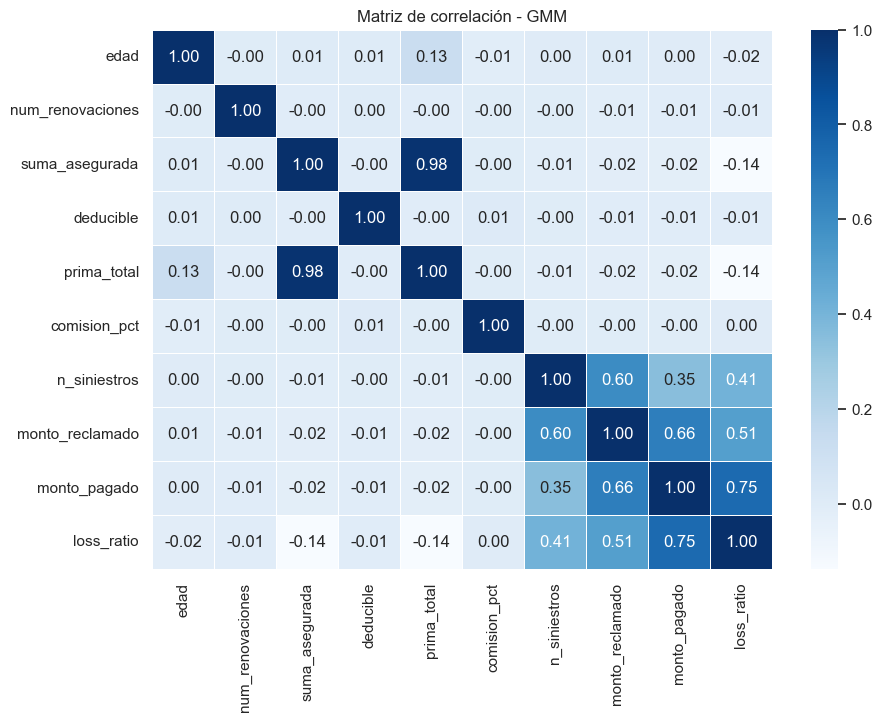

In [27]:
plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="Blues", linewidths=0.5)
plt.title("Matriz de correlación - GMM")
plt.show()

In [27]:
df_gmm = df[df["ramo"]=="GMM"].copy()

df_gmm_reg = df_gmm[df_gmm["monto_pagado"] > 0].copy()

In [30]:
corr = df_gmm_reg[
    [
        "edad",
        "num_renovaciones",
        "suma_asegurada",
        "deducible",
        "monto_pagado_log"
    ]
].corr()

display(corr)

,edad,num_renovaciones,suma_asegurada,deducible,monto_pagado_log
edad,1.00,-0.00,0.03,0.02,0.01
num_renovaciones,-0.00,1.00,0.02,0.02,-0.00
suma_asegurada,0.03,0.02,1.00,0.04,-0.04
deducible,0.02,0.02,0.04,1.00,-0.00
monto_pagado_log,0.01,-0.00,-0.04,-0.00,1.00


### Interpretación

La correlación más alta con `monto_pagado` aparece con `loss_ratio`, `monto_reclamado` y `n_siniestros`. Esto era esperable porque son variables directamente relacionadas con la experiencia de siniestros.

En cambio, variables como edad, prima total, suma asegurada o deducible no muestran una relación lineal fuerte con el monto pagado. 

## 10. Detección de valores atípicos

Nuestro objetivo no es eliminar datos automáticamente, sino identificar qué variables tienen observaciones alejadas del comportamiento central.

In [ ]:
def detectar_outliers_iqr(dataframe, columna):
    q1 = dataframe[columna].quantile(0.25)
    q3 = dataframe[columna].quantile(0.75)
    iqr = q3 - q1
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr
    
    outliers = dataframe[
        (dataframe[columna] < limite_inferior) | 
        (dataframe[columna] > limite_superior)
    ]
    
    return len(outliers), len(outliers) / len(dataframe) * 100, limite_inferior, limite_superior


resumen_outliers = []

for col in [
    "edad", "prima_total", "suma_asegurada", "deducible",
    "n_siniestros", "monto_pagado", "loss_ratio"
]:
    
    n_out, pct_out, lim_inf, lim_sup = detectar_outliers_iqr(df_gmm, col)
    
    resumen_outliers.append({
        "variable": col,
        "outliers": n_out,
        "porcentaje": pct_out,
        "limite_inferior": lim_inf,
        "limite_superior": lim_sup
    })


resumen_outliers = pd.DataFrame(resumen_outliers)


resumen_outliers.style.format({
    "outliers": "{:,.0f}",
    "porcentaje": "{:.2f}%",
    "limite_inferior": "{:,.2f}",
    "limite_superior": "{:,.2f}"
}) \
.set_caption("Detección de valores atípicos mediante método IQR - GMM") \
.set_table_styles([
    {
        "selector": "caption",
        "props": [
            ("font-size", "16px"),
            ("font-weight", "bold"),
            ("text-align", "center")
        ]
    },
    {
        "selector": "th",
        "props": [
            ("font-weight", "bold"),
            ("text-align", "center")
        ]
    },
    {
        "selector": "td",
        "props": [
            ("text-align", "center")
        ]
    }
])

,variable,outliers,porcentaje,limite_inferior,limite_superior
0,edad,0,0.00%,-1.00,87.00
1,prima_total,0,0.00%,"-55,123.20","117,187.84"
2,suma_asegurada,0,0.00%,"-2,250,000.00","4,550,000.00"
3,deducible,0,0.00%,"-2,500.00","25,500.00"
4,n_siniestros,121,0.54%,-1.50,2.50
5,monto_pagado,"2,813",12.49%,0.00,0.00
6,loss_ratio,"2,813",12.49%,0.00,0.00


### Interpretación de los valores atípicos

Los valores atípicos se concentran principalmente en `monto_pagado` y `loss_ratio`, con alrededor de **12.49%** de observaciones marcadas como atípicas. Esto tiene sentido porque los pagos de siniestros no suelen distribuirse de forma pareja: muchos son cero o bajos, pero algunos eventos pueden ser muy costosos.

En este caso no conviene borrar esos registros sólo por ser atípicos, porque en GMM justamente los casos extremos son parte del riesgo que debe analizarse. Más bien debemos tratarlos con cuidado, usando transformaciones o modelos que no dependan únicamente del promedio.

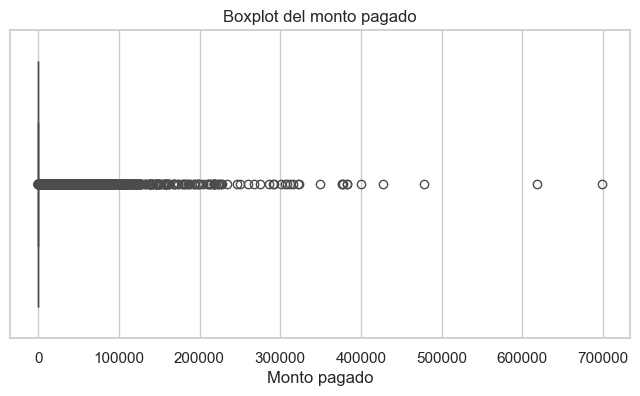

In [30]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df_gmm["monto_pagado"])
plt.title("Boxplot del monto pagado")
plt.xlabel("Monto pagado")
plt.show()

### Interpretación boxplot del monto pagado

El boxplot muestra muchos puntos alejados del cuerpo principal de la distribución. Estos puntos representan pagos más altos que el resto de la cartera.

No sólo importa cuántos siniestros ocurren, sino cuánto puede costar cada uno. Los pagos extremos pueden afectar reservas, tarifas y análisis de rentabilidad, por lo que deben considerarse en la interpretación del modelo.

## 11. Preparación para modelos

Se trabajará con dos enfoques:

1. **Modelo de regresión lineal:** para estimar el monto pagado transformado con logaritmo.
2. **Modelo de regresión logística:** para estimar si una póliza tuvo o no siniestro.
3. **Random Forest:** para comparar si un modelo no lineal logra capturar mejor el comportamiento del monto pagado.

Para evitar fuga de información, no se usan variables que ya conocen directamente el resultado del siniestro, como `monto_reclamado`, `n_siniestros`, `loss_ratio` o `nivel_riesgo`.

In [ ]:
variables_num_modelo = [
    "edad", "num_renovaciones", "suma_asegurada",
    "deducible"
]

variables_cat_modelo = [
    "sexo", "estado_civil", "canal_venta", "region",
    "tipo_agente", "plan", "forma_pago"
]

X = df_gmm[variables_num_modelo + variables_cat_modelo].copy()
y_reg = df_gmm["monto_pagado_log"].copy()
y_clf = df_gmm["siniestro_positivo"].copy()

preprocesamiento = ColumnTransformer(
    transformers=[
        ("num", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), variables_num_modelo),
        
        ("cat", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first"))
        ]), variables_cat_modelo)
    ]
)

### Comentario

En esta parte se decidió no meter variables que ya traen información directa del siniestro. Por ejemplo, si usamos `loss_ratio` o `n_siniestros` para predecir el monto pagado, el modelo podría verse "perfecto", pero en realidad estaría usando información que normalmente no se tendría antes de que ocurra el siniestro.

Por eso se usan variables más relacionadas con la póliza, el asegurado y la forma de contratación. Así el resultado es más "real".

## 12. Modelo 1: Regresión lineal para monto pagado

Se ajusta una regresión lineal usando como variable objetivo el logaritmo del monto pagado. El objetivo es revisar qué tan bien las características disponibles explican el costo del siniestro.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_reg, test_size=0.25, random_state=99
)

modelo_lineal = Pipeline(steps=[
    ("preprocesamiento", preprocesamiento),
    ("modelo", LinearRegression())
])

modelo_lineal.fit(X_train, y_train)

y_pred_lineal = modelo_lineal.predict(X_test)


metricas_lineal = pd.DataFrame({
    "modelo": ["Regresión lineal"],
    "MAE": [mean_absolute_error(y_test, y_pred_lineal)],
    "RMSE": [np.sqrt(mean_squared_error(y_test, y_pred_lineal))],
    "R2": [r2_score(y_test, y_pred_lineal)]
})


metricas_lineal.style.format({
    "MAE": "{:,.2f}",
    "RMSE": "{:,.2f}",
    "R2": "{:.9f}"
}) \
.set_caption("Resultados del modelo de Regresión Lineal") \
.set_table_styles([
    {
        "selector": "caption",
        "props": [
            ("font-size", "16px"),
            ("font-weight", "bold"),
            ("text-align", "center")
        ]
    },
    {
        "selector": "th",
        "props": [
            ("font-weight", "bold"),
            ("text-align", "center")
        ]
    },
    {
        "selector": "td",
        "props": [
            ("text-align", "center")
        ]
    }
])

,modelo,MAE,RMSE,R2
0,Regresión lineal,2.11,3.21,-0.000760397


### Interpretación

La regresión lineal no logra explicar bien el monto pagado, ya que el **R² es cercano a cero**. Esto indica que, con las variables disponibles antes del siniestro, el monto pagado es difícil de anticipar de forma lineal.

In [ ]:
nombres_variables = modelo_lineal.named_steps["preprocesamiento"].get_feature_names_out()
coeficientes = modelo_lineal.named_steps["modelo"].coef_

coef_lineal = pd.DataFrame({
    "variable": nombres_variables,
    "coeficiente": coeficientes
})

coef_lineal["abs_coeficiente"] = coef_lineal["coeficiente"].abs()

coef_lineal = coef_lineal.sort_values(
    "abs_coeficiente", 
    ascending=False
)


coef_lineal.head(12).style.format({
    "coeficiente": "{:.5f}",
    "abs_coeficiente": "{:.5f}"
}) \
.set_caption("Principales coeficientes del modelo de Regresión Lineal") \
.set_table_styles([
    {
        "selector": "caption",
        "props": [
            ("font-size", "16px"),
            ("font-weight", "bold"),
            ("text-align", "center")
        ]
    },
    {
        "selector": "th",
        "props": [
            ("font-weight", "bold"),
            ("text-align", "center")
        ]
    },
    {
        "selector": "td",
        "props": [
            ("text-align", "center")
        ]
    }
])

,variable,coeficiente,abs_coeficiente
15,cat__canal_venta_Promotor,-0.21347,0.21347
2,num__suma_asegurada,-0.19150,0.19150
31,cat__tipo_agente_Promotor,0.16010,0.16010
4,num__prima_total,0.15730,0.15730
20,cat__region_Guanajuato,0.14583,0.14583
18,cat__region_Coahuila,-0.13605,0.13605
28,cat__region_Veracruz,-0.12721,0.12721
13,cat__canal_venta_Digital,0.11363,0.11363
6,cat__sexo_M,-0.11103,0.11103
37,cat__forma_pago_Trimestral,0.10291,0.10291


### Interpretación

Los coeficientes más altos aparecen en variables como canal de venta, suma asegurada, prima total y tipo de agente. Como la variable objetivo está en logaritmo, los signos se interpretan como aumentos o disminuciones en el monto pagado transformado.

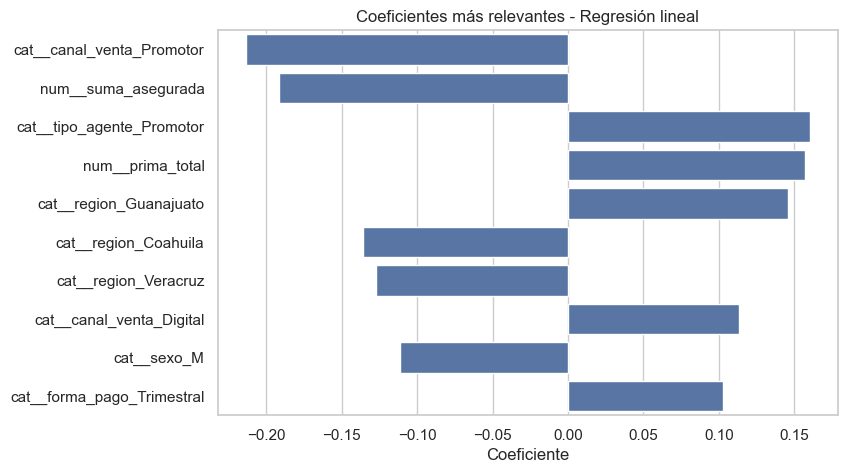

In [42]:
plt.figure(figsize=(8, 5))
sns.barplot(
    data=coef_lineal.head(10),
    x="coeficiente",
    y="variable"
)
plt.title("Coeficientes más relevantes - Regresión lineal")
plt.xlabel("Coeficiente")
plt.ylabel("")
plt.show()

### Interpretación de la gráfica de coeficientes

La gráfica ayuda a ver cuáles variables empujan el resultado hacia arriba o hacia abajo dentro del modelo lineal. Se observan diferencias entre categorías de canal, región o tipo de agente, además de variables numéricas como prima y suma asegurada.

Sin embargo, como el desempeño general del modelo es bajo, parece que las variables de contratación ayudan un poco, pero no capturan por completo el comportamiento de la severidad en GMM.

## 13. Modelo 2: Regresión logística para ocurrencia de siniestro

Ahora se modela si la póliza tuvo o no al menos un siniestro. Este modelo se enfoca en frecuencia, no en severidad.

In [24]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Usamos el mismo split que en la regresión lineal
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_reg,
    test_size=0.25,
    random_state=99
)

resultados_poly = []
modelos_poly = {}

for grado in [1, 2, 3]:

    preprocesamiento_poly = ColumnTransformer(
        transformers=[
            ("num", Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
                ("poly", PolynomialFeatures(degree=grado, include_bias=False))
            ]), variables_num_modelo),

            ("cat", Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first"))
            ]), variables_cat_modelo)
        ]
    )

    modelo_poly = Pipeline(steps=[
        ("preprocesamiento", preprocesamiento_poly),
        ("modelo", LinearRegression())
    ])

    modelo_poly.fit(X_train, y_train)

    y_pred_train = modelo_poly.predict(X_train)
    y_pred_test = modelo_poly.predict(X_test)

    resultados_poly.append({
        "modelo": f"Polinómica grado {grado}",
        "MAE train": mean_absolute_error(y_train, y_pred_train),
        "MAE test": mean_absolute_error(y_test, y_pred_test),
        "RMSE train": np.sqrt(mean_squared_error(y_train, y_pred_train)),
        "RMSE test": np.sqrt(mean_squared_error(y_test, y_pred_test)),
        "R2 train": r2_score(y_train, y_pred_train),
        "R2 test": r2_score(y_test, y_pred_test)
    })

    modelos_poly[grado] = modelo_poly

metricas_poly = pd.DataFrame(resultados_poly)

metricas_poly.style.format({
    "MAE train": "{:,.5f}",
    "MAE test": "{:,.5f}",
    "RMSE train": "{:,.5f}",
    "RMSE test": "{:,.5f}",
    "R2 train": "{:.5f}",
    "R2 test": "{:.5f}"
}).set_caption("Comparación de regresión lineal y polinómica")

,modelo,MAE train,MAE test,RMSE train,RMSE test,R2 train,R2 test
0,Polinómica grado 1,1.00686,1.00058,1.29672,1.30201,0.01678,-0.03446
1,Polinómica grado 2,1.00477,1.00165,1.29443,1.30362,0.02026,-0.03702
2,Polinómica grado 3,1.00316,1.00398,1.29057,1.30863,0.02609,-0.04500


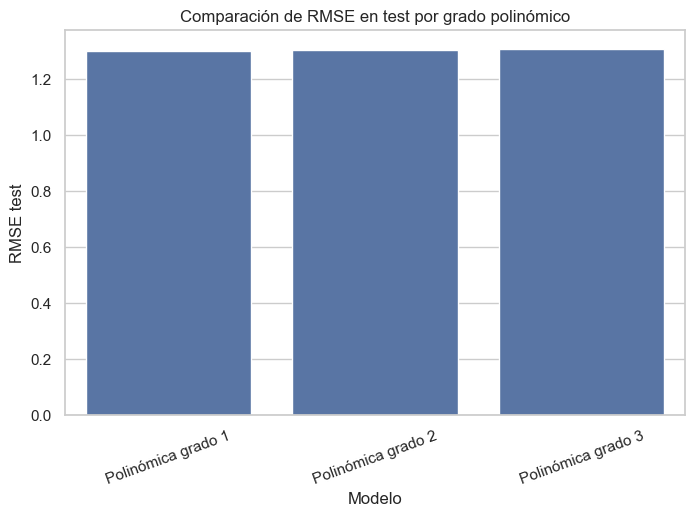

In [25]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=metricas_poly,
    x="modelo",
    y="RMSE test"
)

plt.title("Comparación de RMSE en test por grado polinómico")
plt.xlabel("Modelo")
plt.ylabel("RMSE test")
plt.xticks(rotation=20)
plt.show()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_clf, 
    test_size=0.25, 
    random_state=99, 
    stratify=y_clf
)

modelo_logistico = Pipeline(steps=[
    ("preprocesamiento", preprocesamiento),
    ("modelo", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

modelo_logistico.fit(X_train, y_train)

y_pred_log = modelo_logistico.predict(X_test)
y_prob_log = modelo_logistico.predict_proba(X_test)[:, 1]


metricas_log = pd.DataFrame({
    "modelo": ["Regresión logística"],
    "accuracy": [accuracy_score(y_test, y_pred_log)],
    "precision": [precision_score(y_test, y_pred_log)],
    "recall": [recall_score(y_test, y_pred_log)],
    "f1": [f1_score(y_test, y_pred_log)],
    "roc_auc": [roc_auc_score(y_test, y_prob_log)]
})


metricas_log.style.format({
    "accuracy": "{:.5f}",
    "precision": "{:.5f}",
    "recall": "{:.5f}",
    "f1": "{:.5f}",
    "roc_auc": "{:.5f}"
}) \
.set_caption("Resultados del modelo de Regresión Logística") \
.set_table_styles([
    {
        "selector": "caption",
        "props": [
            ("font-size", "16px"),
            ("font-weight", "bold"),
            ("text-align", "center")
        ]
    },
    {
        "selector": "th",
        "props": [
            ("font-weight", "bold"),
            ("text-align", "center")
        ]
    },
    {
        "selector": "td",
        "props": [
            ("text-align", "center")
        ]
    }
])

,modelo,accuracy,precision,recall,f1,roc_auc
0,Regresión logística,0.50453,0.30103,0.47750,0.36927,0.49660


### Interpretación

La regresión logística tiene un desempeño bajo para separar pólizas con y sin siniestro. El **Area bajo la Curva queda cercana a 0.50**, lo que indica que el modelo casi no distingue mejor que una clasificación al azar.

Esto es importante porque muestra que la ocurrencia del siniestro no se explica fácilmente con las variables generales disponibles, esto puede pasar cuando faltan variables más específicas del riesgo médico, como historial clínico, padecimientos, uso hospitalario o información más detallada del asegurado.

In [ ]:
matriz_confusion = confusion_matrix(y_test, y_pred_log)

matriz_confusion = pd.DataFrame(
    matriz_confusion,
    index=["Real: Sin siniestro", "Real: Con siniestro"],
    columns=["Predicción: Sin siniestro", "Predicción: Con siniestro"]
)


matriz_confusion.style.format("{:,.0f}") \
    .set_caption("Matriz de confusión - Regresión Logística") \
    .set_table_styles([
        {
            "selector": "caption",
            "props": [
                ("font-size", "16px"),
                ("font-weight", "bold"),
                ("text-align", "center")
            ]
        },
        {
            "selector": "th",
            "props": [
                ("font-weight", "bold"),
                ("text-align", "center")
            ]
        },
        {
            "selector": "td",
            "props": [
                ("text-align", "center")
            ]
        }
    ])

,Predicción: Sin siniestro,Predicción: Con siniestro
Real: Sin siniestro,"2,025","1,897"
Real: Con siniestro,894,817


### Interpretación de la matriz de confusión

La matriz de confusión muestra que el modelo comete varios errores tanto en pólizas con siniestro como en pólizas sin siniestro. Esto confirma que no hay una separación clara entre ambos grupos usando sólo estas variables.

En la práctica, esto significa que el modelo no sería suficiente por sí solo para tomar decisiones de suscripción o tarificación. Serviría más como una primera prueba, pero haría falta enriquecer la información para mejorar la predicción de frecuencia.

In [ ]:
nombres_variables_log = modelo_logistico.named_steps["preprocesamiento"].get_feature_names_out()
coef_log = modelo_logistico.named_steps["modelo"].coef_[0]

coef_logistico = pd.DataFrame({
    "variable": nombres_variables_log,
    "coeficiente": coef_log,
    "odds_ratio": np.exp(coef_log)
})

coef_logistico["abs_coeficiente"] = coef_logistico["coeficiente"].abs()

coef_logistico = coef_logistico.sort_values(
    "abs_coeficiente", 
    ascending=False
)


coef_logistico.head(12).style.format({
    "coeficiente": "{:.6f}",
    "odds_ratio": "{:.6f}",
    "abs_coeficiente": "{:.6f}"
}) \
.set_caption("Principales coeficientes del modelo de Regresión Logística") \
.set_table_styles([
    {
        "selector": "caption",
        "props": [
            ("font-size", "16px"),
            ("font-weight", "bold"),
            ("text-align", "center")
        ]
    },
    {
        "selector": "th",
        "props": [
            ("font-weight", "bold"),
            ("text-align", "center")
        ]
    },
    {
        "selector": "td",
        "props": [
            ("text-align", "center")
        ]
    }
])

,variable,coeficiente,odds_ratio,abs_coeficiente
4,num__prima_total,-0.228883,0.795422,0.228883
2,num__suma_asegurada,0.210454,1.234238,0.210454
15,cat__canal_venta_Promotor,-0.137049,0.871927,0.137049
17,cat__region_Chihuahua,-0.113367,0.892823,0.113367
28,cat__region_Veracruz,-0.106884,0.898630,0.106884
19,cat__region_Estado de Mexico,-0.102618,0.902472,0.102618
26,cat__region_Sonora,0.093000,1.097461,0.093000
36,cat__forma_pago_Semestral,0.084429,1.088096,0.084429
31,cat__tipo_agente_Promotor,0.079595,1.082849,0.079595
30,cat__tipo_agente_Independiente,0.079392,1.082628,0.079392


### Interpretación de coeficientes de la regresión logística

Los coeficientes indican cómo cambia la probabilidad estimada de tener siniestro. Un `odds_ratio` mayor a 1 aumenta la razón de probabilidades, mientras que uno menor a 1 la disminuye.

En los resultados aparecen variables como prima total, suma asegurada, canal de venta y algunas regiones. Aun así, como el poder predictivo del modelo es débil, estos efectos no deben leerse como reglas definitivas.

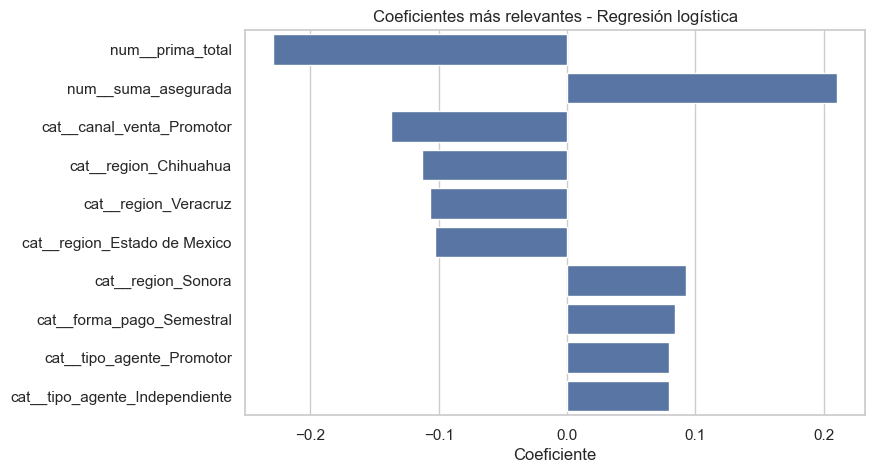

In [52]:
plt.figure(figsize=(8, 5))
sns.barplot(
    data=coef_logistico.head(10),
    x="coeficiente",
    y="variable"
)
plt.title("Coeficientes más relevantes - Regresión logística")
plt.xlabel("Coeficiente")
plt.ylabel("")
plt.show()

### Interpretación

La gráfica permite ubicar rápidamente las variables que más mueven la probabilidad estimada de siniestro dentro del modelo. Se observan efectos positivos y negativos, pero ninguno logra construir una separación fuerte entre pólizas siniestradas y no siniestradas.

Esto refuerza la idea de que la frecuencia de siniestros en GMM necesita variables más detalladas para poder modelarse mejor.

## 14. Modelo 3: Random Forest para monto pagado

Se ajusta un Random Forest como alternativa no lineal. La idea es revisar si un modelo más flexible logra capturar patrones que la regresión lineal no alcanza a representar.

In [55]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_reg, 
    test_size=0.25, 
    random_state=99
)

modelo_rf = Pipeline(steps=[
    ("preprocesamiento", preprocesamiento),
    ("modelo", RandomForestRegressor(
        n_estimators=100,
        max_depth=8,
        min_samples_leaf=30,
        random_state=99,
        n_jobs=-1
    ))
])

modelo_rf.fit(X_train, y_train)

y_pred_rf = modelo_rf.predict(X_test)


metricas_rf = pd.DataFrame({
    "modelo": ["Random Forest"],
    "MAE": [mean_absolute_error(y_test, y_pred_rf)],
    "RMSE": [np.sqrt(mean_squared_error(y_test, y_pred_rf))],
    "R2": [r2_score(y_test, y_pred_rf)]
})


metricas_rf.style.format({
    "MAE": "{:,.5f}",
    "RMSE": "{:,.5f}",
    "R2": "{:.5f}"
}) \
.set_caption("Resultados del modelo Random Forest") \
.set_table_styles([
    {
        "selector": "caption",
        "props": [
            ("font-size", "16px"),
            ("font-weight", "bold"),
            ("text-align", "center")
        ]
    },
    {
        "selector": "th",
        "props": [
            ("font-weight", "bold"),
            ("text-align", "center")
        ]
    },
    {
        "selector": "td",
        "props": [
            ("text-align", "center")
        ]
    }
])

,modelo,MAE,RMSE,R2
0,Random Forest,2.11349,3.21528,-0.00196


### Interpretación

El Random Forest tampoco mejora de forma importante la explicación del monto pagado. Su **R² también queda cercano a cero**, por lo que el modelo no logra capturar suficiente señal con las variables usadas.

In [57]:
importancias_rf = pd.DataFrame({
    "variable": modelo_rf.named_steps["preprocesamiento"].get_feature_names_out(),
    "importancia": modelo_rf.named_steps["modelo"].feature_importances_
}).sort_values(
    "importancia", 
    ascending=False
)


# Formato de presentación de importancia de variables
importancias_rf.head(12).style.format({
    "importancia": "{:.6f}"
}) \
.set_caption("Importancia de variables - Random Forest") \
.set_table_styles([
    {
        "selector": "caption",
        "props": [
            ("font-size", "16px"),
            ("font-weight", "bold"),
            ("text-align", "center")
        ]
    },
    {
        "selector": "th",
        "props": [
            ("font-weight", "bold"),
            ("text-align", "center")
        ]
    },
    {
        "selector": "td",
        "props": [
            ("text-align", "center")
        ]
    }
])

,variable,importancia
4,num__prima_total,0.220637
5,num__comision_pct,0.169460
0,num__edad,0.164213
3,num__deducible,0.064174
1,num__num_renovaciones,0.049523
6,cat__sexo_M,0.035292
30,cat__tipo_agente_Independiente,0.019839
8,cat__estado_civil_Soltero,0.018024
31,cat__tipo_agente_Promotor,0.016505
33,cat__plan_Plus,0.015573


### Interpretació

Las variables con mayor importancia son prima total, comisión, edad y deducible. Esto sugiere que el modelo sí encuentra algo de información en las características de la póliza y del asegurado.

Aunque el modelo ordena variables, el resultado general indica que todavía falta información para explicar adecuadamente los pagos. En otras palabras, estas variables ayudan a segmentar un poco, pero no son suficientes para predecir severidad individual.

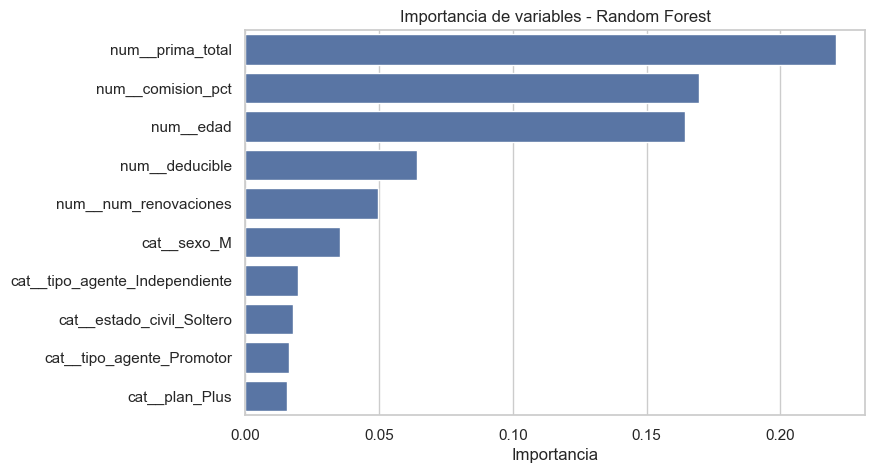

In [58]:
plt.figure(figsize=(8, 5))
sns.barplot(
    data=importancias_rf.head(10),
    x="importancia",
    y="variable"
)
plt.title("Importancia de variables - Random Forest")
plt.xlabel("Importancia")
plt.ylabel("")
plt.show()

### Interpretación

La gráfica muestra que el Random Forest se apoya principalmente en variables económicas de la póliza y en edad. Esto tiene lógica porque prima, deducible y suma asegurada resumen parte de la estructura del producto y del riesgo que se aceptó.

Sin embargo, la baja capacidad predictiva indica que la severidad de GMM no queda explicada sólo por esas variables.

## 15. Comparación de modelos

Finalmente comparamos los modelos de severidad. Ambos usan como objetivo el logaritmo del monto pagado.

In [60]:
comparacion_modelos = pd.concat(
    [metricas_lineal, metricas_rf], 
    ignore_index=True
)


# Formato de presentación de comparación de modelos
comparacion_modelos.style.format({
    "MAE": "{:,.5f}",
    "RMSE": "{:,.5f}",
    "R2": "{:.5f}"
}) \
.set_caption("Comparación de desempeño entre modelos") \
.set_table_styles([
    {
        "selector": "caption",
        "props": [
            ("font-size", "16px"),
            ("font-weight", "bold"),
            ("text-align", "center")
        ]
    },
    {
        "selector": "th",
        "props": [
            ("font-weight", "bold"),
            ("text-align", "center")
        ]
    },
    {
        "selector": "td",
        "props": [
            ("text-align", "center")
        ]
    }
])

,modelo,MAE,RMSE,R2
0,Regresión lineal,2.11283,3.21336,-0.00076
1,Random Forest,2.11349,3.21528,-0.00196


### Interpretación de la comparación

La comparación muestra que ni la regresión lineal ni el Random Forest logran explicar bien el monto pagado. Lo que sugiere que el problema no está sólo en elegir un modelo más complejo.

La principal lectura es que el monto pagado en GMM tiene mucha variabilidad y depende de información que no está completamente representada en las variables de cartera. Para fines actuariales, esto justifica analizar la severidad con cuidado, revisar colas.

## 16. Comentarios

1. Se seleccionó el ramo **GMM** porque es el que tiene mayor número de registros dentro de la base y porque actuarialmente permite analizar frecuencia y severidad de siniestros.

2. En el análisis exploratorio se observó que muchas pólizas no presentan siniestros, pero existen pagos altos que generan una cola importante en la distribución de `monto_pagado`. Esto es consistente con el comportamiento esperado en Gastos Médicos Mayores.

3. Las estadísticas descriptivas y los boxplots muestran que los valores atípicos no necesariamente son errores. En este ramo pueden representar casos médicos de alta severidad, por lo que deben analizarse y no eliminarse automáticamente.

4. La matriz de correlación indica que las variables más relacionadas con `monto_pagado` son las que ya están conectadas directamente con siniestros, como `monto_reclamado`, `n_siniestros` y `loss_ratio`. Las variables generales de póliza muestran relaciones más débiles.

5. En los modelos, tanto la regresión lineal como el Random Forest tuvieron bajo poder explicativo para el monto pagado. La regresión logística tampoco separó bien las pólizas con y sin siniestro.

6. Desde un enfoque actuarial, el resultado más importante es que la cartera presenta baja frecuencia relativa de siniestros, pero con severidad potencialmente alta. 
